Cargando datos de dataset_reclamos_ia_ruidoso_extremo.xlsx...
Analizando patrones psicológicos en los textos...

--- RESULTADOS DE LA VALIDACIÓN LINGÜÍSTICA ---
Clase 0 = Legítimo | Clase 1 = Fraude

                   Word_Count  Superlativos_Count  Score_Distanciamiento
Prediccion_Fraude                                                       
0                       65.76                0.21                  -3.46
1                       90.20                2.84                   1.35


/var/folders/4x/h75m00b969j2f2r5f8rclwnr0000gn/T/ipykernel_6192/3551470706.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Prediccion_Fraude', y='Word_Count', data=df, ax=axes[0], palette=['#4CAF50', '#F44336'])
/var/folders/4x/h75m00b969j2f2r5f8rclwnr0000gn/T/ipykernel_6192/3551470706.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legítimo', 'Fraude'])
/var/folders/4x/h75m00b969j2f2r5f8rclwnr0000gn/T/ipykernel_6192/3551470706.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Prediccion_Fraude', y='Superlativos_Count', data=df, ax=axes[1], palette=['#4CAF50', '#


Gráficas guardadas como 'validacion_marcadores_fraude.png'. ¡Listas para la presentación!


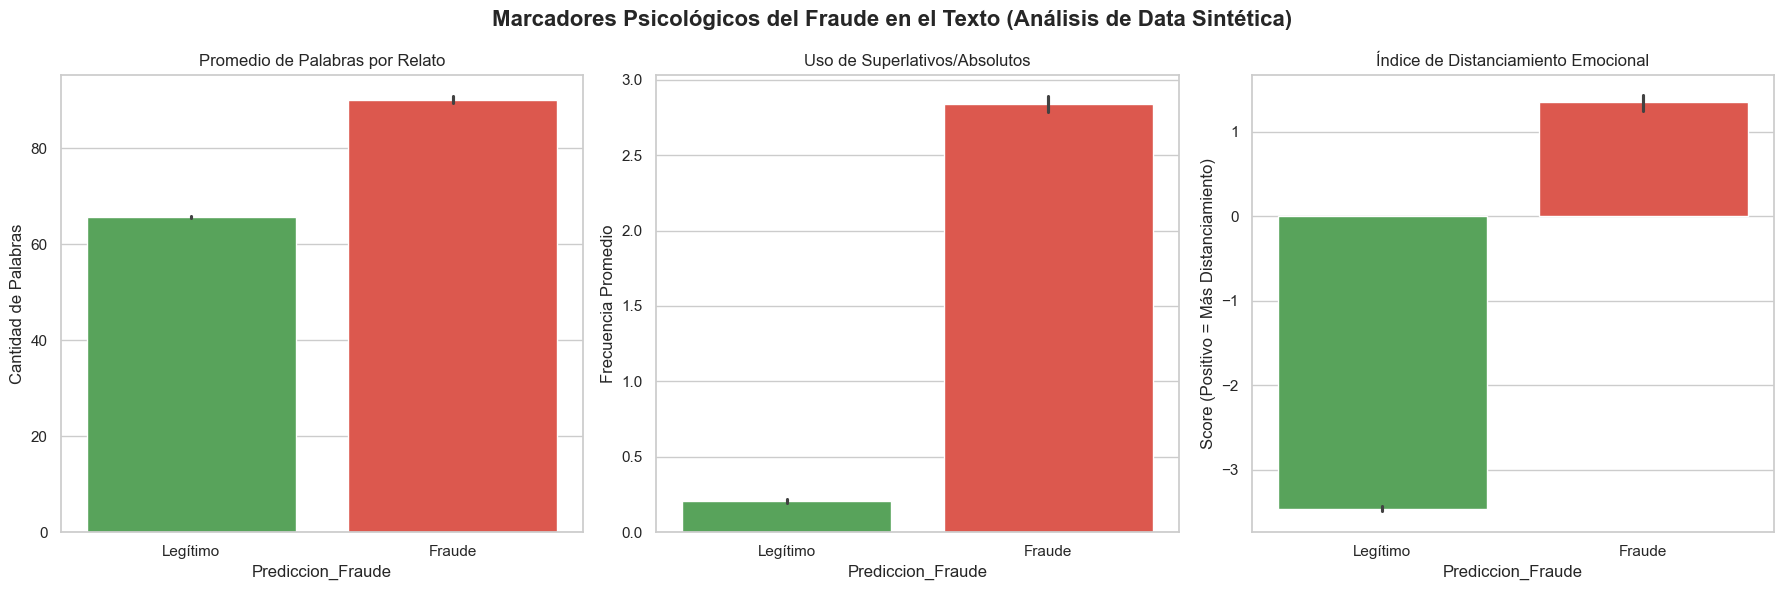

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 1. Cargar el dataset generado
ARCHIVO_EXCEL = "dataset_reclamos_ia_ruidoso_extremo.xlsx"
print(f"Cargando datos de {ARCHIVO_EXCEL}...")
df = pd.read_excel(ARCHIVO_EXCEL)

# Limpiar nulos por si el ruido inyectó algún NaN en la descripción
df['Claim_Description'] = df['Claim_Description'].fillna("")

# 2. Definir funciones de extracción de características lingüísticas

def contar_palabras(texto):
    return len(str(texto).split())

def contar_superlativos(texto):
    # Palabras que denotan exceso de justificación
    patron = r'\b(absolutamente|completamente|totalmente|perfectamente|exactamente|excesivamente|definitivamente|imposible)\b'
    matches = re.findall(patron, str(texto).lower())
    return len(matches)

def indice_distanciamiento(texto):
    texto = str(texto).lower()
    # Pronombres personales (El cliente asume la situación)
    personales = len(re.findall(r'\b(yo|me|mi|mis)\b', texto))
    # Lenguaje pasivo/distante (El cliente se aleja del accidente)
    impersonales = len(re.findall(r'\b(el vehículo|la unidad|el auto|se produjo|fue impactado|resultó)\b', texto))
    
    # Retornamos la diferencia: un número positivo alto significa más distanciamiento
    # Si usa muchos "yo/me", el número será negativo o cercano a cero.
    return impersonales - personales

# 3. Aplicar funciones al dataset
print("Analizando patrones psicológicos en los textos...")
df['Word_Count'] = df['Claim_Description'].apply(contar_palabras)
df['Superlativos_Count'] = df['Claim_Description'].apply(contar_superlativos)
df['Score_Distanciamiento'] = df['Claim_Description'].apply(indice_distanciamiento)

# 4. Agrupar y comparar estadísticas entre Legítimos (0) y Fraudes (1)
estadisticas = df.groupby('Prediccion_Fraude')[['Word_Count', 'Superlativos_Count', 'Score_Distanciamiento']].mean().round(2)

print("\n--- RESULTADOS DE LA VALIDACIÓN LINGÜÍSTICA ---")
print("Clase 0 = Legítimo | Clase 1 = Fraude\n")
print(estadisticas)

# 5. Generar gráficas para la presentación
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Marcadores Psicológicos del Fraude en el Texto (Análisis de Data Sintética)', fontsize=16, fontweight='bold')

# Gráfico 1: Longitud del relato
sns.barplot(x='Prediccion_Fraude', y='Word_Count', data=df, ax=axes[0], palette=['#4CAF50', '#F44336'])
axes[0].set_title('Promedio de Palabras por Relato')
axes[0].set_xticklabels(['Legítimo', 'Fraude'])
axes[0].set_ylabel('Cantidad de Palabras')

# Gráfico 2: Uso de Superlativos
sns.barplot(x='Prediccion_Fraude', y='Superlativos_Count', data=df, ax=axes[1], palette=['#4CAF50', '#F44336'])
axes[1].set_title('Uso de Superlativos/Absolutos')
axes[1].set_xticklabels(['Legítimo', 'Fraude'])
axes[1].set_ylabel('Frecuencia Promedio')

# Gráfico 3: Índice de Distanciamiento (Voz Pasiva)
sns.barplot(x='Prediccion_Fraude', y='Score_Distanciamiento', data=df, ax=axes[2], palette=['#4CAF50', '#F44336'])
axes[2].set_title('Índice de Distanciamiento Emocional')
axes[2].set_xticklabels(['Legítimo', 'Fraude'])
axes[2].set_ylabel('Score (Positivo = Más Distanciamiento)')

plt.tight_layout()
plt.savefig("validacion_marcadores_fraude.png", dpi=300)
print("\nGráficas guardadas como 'validacion_marcadores_fraude.png'. ¡Listas para la presentación!")
plt.show()